# Kernel Density Estimation (KDE) and Kernel Functions

This notebook summarizes the key ideas we discussed about:

- discrete vs continuous probability,
- sums vs integrals,
- histogram vs KDE,
- the KDE formula,
- what a kernel means,
- the roles of \(x_i\), \(n\), and bandwidth \(h\),
- common kernel functions,
- how changing \(h\) and \(n\) changes the KDE.

The notebook is written as a compact tutorial with plots.

In [11]:
"""Add plot template details"""

import matplotlib.pyplot as plt
import numpy as np


# Styling
base_fontsize = 18
linewidth = 1.5

niceblue = "#4d7da7"
nicered = "#e15656"
nicegray = "#6e6e6e"

plt.rcParams["figure.dpi"] = 600
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

plt.rcParams["lines.linewidth"] = linewidth
plt.rcParams["axes.labelsize"] = base_fontsize
plt.rcParams["axes.titlesize"] = base_fontsize
plt.rcParams["xtick.labelsize"] = base_fontsize - 3
plt.rcParams["ytick.labelsize"] = base_fontsize - 3

plt.rcParams["legend.fontsize"] = base_fontsize - 4
plt.rcParams["legend.frameon"] = True
plt.rcParams["legend.facecolor"] = "white"
plt.rcParams["legend.edgecolor"] = "#e0e0e0"
plt.rcParams["legend.loc"] = "upper right"

## 1. Core intuition

### Discrete vs continuous

For a **discrete** random variable, probabilities are added with a sum:

\[
P(X \in A) = \sum_{x \in A} P(X=x)
\]

For a **continuous** random variable, probabilities are computed with an integral:

\[
P(X \in A) = \int_A f(x)\,dx
\]

### Histogram vs KDE

A histogram groups observations into bins.

A **Kernel Density Estimator (KDE)** is a smooth, continuous analogue of a histogram.

The main idea is:

\[
	ext{data points} 
ightarrow 	ext{small local curves} 
ightarrow 	ext{average them} 
ightarrow 	ext{smooth density estimate}
\]

## 2. KDE formula

For observations \(x_1, x_2, \dots, x_n\), the KDE is

\[
\hat f_h(x) = 
rac{1}{nh} \sum_{i=1}^{n} K\left(
rac{x-x_i}{h}
ight)
\]

where:

- \(x_i\): observed data values,
- \(n\): number of observations,
- \(K\): kernel function,
- \(h\): bandwidth,
- \(\hat f_h(x)\): estimated density at point \(x\).

### What each part means

- The **kernel** gives the shape placed around each observation.
- The **bandwidth** \(h\) controls the width of that shape.
- The **sample size** \(n\) is just the number of observations.

Important distinction:

- \(h\) is a tuning choice,
- \(n\) is not chosen as a shape parameter; it comes from the data size.

## 3. Gaussian kernel

A common kernel choice is the **Gaussian kernel**:

\[
K(u) = 
rac{1}{\sqrt{2\pi}} e^{-u^2/2}
\]

Then the KDE becomes

\[
\hat f_h(x)
=

rac{1}{nh\sqrt{2\pi}}
\sum_{i=1}^{n}
\exp\left(-
rac{(x-x_i)^2}{2h^2}
ight)
\]

Interpretation:

- each observation gets a bell-shaped curve,
- the curve is centered at that observation,
- nearby values receive higher weight than faraway values.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Dict

In [13]:
# Example observations used throughout the notebook
observations = np.array([1.0, 2.0, 2.5, 4.0, 5.0])
n_samples = observations.size
bandwidth = 0.6
x_grid = np.linspace(-0.5, 6.5, 1000)

print(f"Observations: {observations}")
print(f"n = {n_samples}")
print(f"h = {bandwidth}")

Observations: [1.  2.  2.5 4.  5. ]
n = 5
h = 0.6


## 4. Kernel functions used in practice

Below are several common kernel functions:

### Gaussian
\[
K(u)=
rac{1}{\sqrt{2\pi}}e^{-u^2/2}
\]

### Uniform
\[
K(u)=
egin{cases}

rac{1}{2}, & |u|\le 1 \
0, & |u|>1
\end{cases}
\]

### Triangular
\[
K(u)=
egin{cases}
1-|u|, & |u|\le 1 \
0, & |u|>1
\end{cases}
\]

### Epanechnikov
\[
K(u)=
egin{cases}

rac{3}{4}(1-u^2), & |u|\le 1 \
0, & |u|>1
\end{cases}
\]

### Biweight
\[
K(u)=
egin{cases}

rac{15}{16}(1-u^2)^2, & |u|\le 1 \
0, & |u|>1
\end{cases}
\]

### Cosine
\[
K(u)=
egin{cases}

rac{\pi}{4}\cos\left(
rac{\pi u}{2}
ight), & |u|\le 1 \
0, & |u|>1
\end{cases}
\]

The constants ensure that the kernel integrates to 1:

\[
\int_{-\infty}^{\infty} K(u)\,du = 1
\]

In [14]:
def gaussian_kernel(u: np.ndarray) -> np.ndarray:
    return np.exp(-0.5 * u**2) / np.sqrt(2.0 * np.pi)


def uniform_kernel(u: np.ndarray) -> np.ndarray:
    return 0.5 * (np.abs(u) <= 1.0)


def triangular_kernel(u: np.ndarray) -> np.ndarray:
    return np.maximum(1.0 - np.abs(u), 0.0)


def epanechnikov_kernel(u: np.ndarray) -> np.ndarray:
    values = 0.75 * (1.0 - u**2)
    return np.where(np.abs(u) <= 1.0, values, 0.0)


def biweight_kernel(u: np.ndarray) -> np.ndarray:
    values = (15.0 / 16.0) * (1.0 - u**2) ** 2
    return np.where(np.abs(u) <= 1.0, values, 0.0)


def cosine_kernel(u: np.ndarray) -> np.ndarray:
    values = (np.pi / 4.0) * np.cos((np.pi * u) / 2.0)
    return np.where(np.abs(u) <= 1.0, values, 0.0)


kernel_functions: Dict[str, Callable[[np.ndarray], np.ndarray]] = {
    "Gaussian": gaussian_kernel,
    "Uniform": uniform_kernel,
    "Triangular": triangular_kernel,
    "Epanechnikov": epanechnikov_kernel,
    "Biweight": biweight_kernel,
    "Cosine": cosine_kernel,
}

## 5. Plot the kernel functions themselves

This plot shows only the shapes of the kernel functions \(K(u)\).

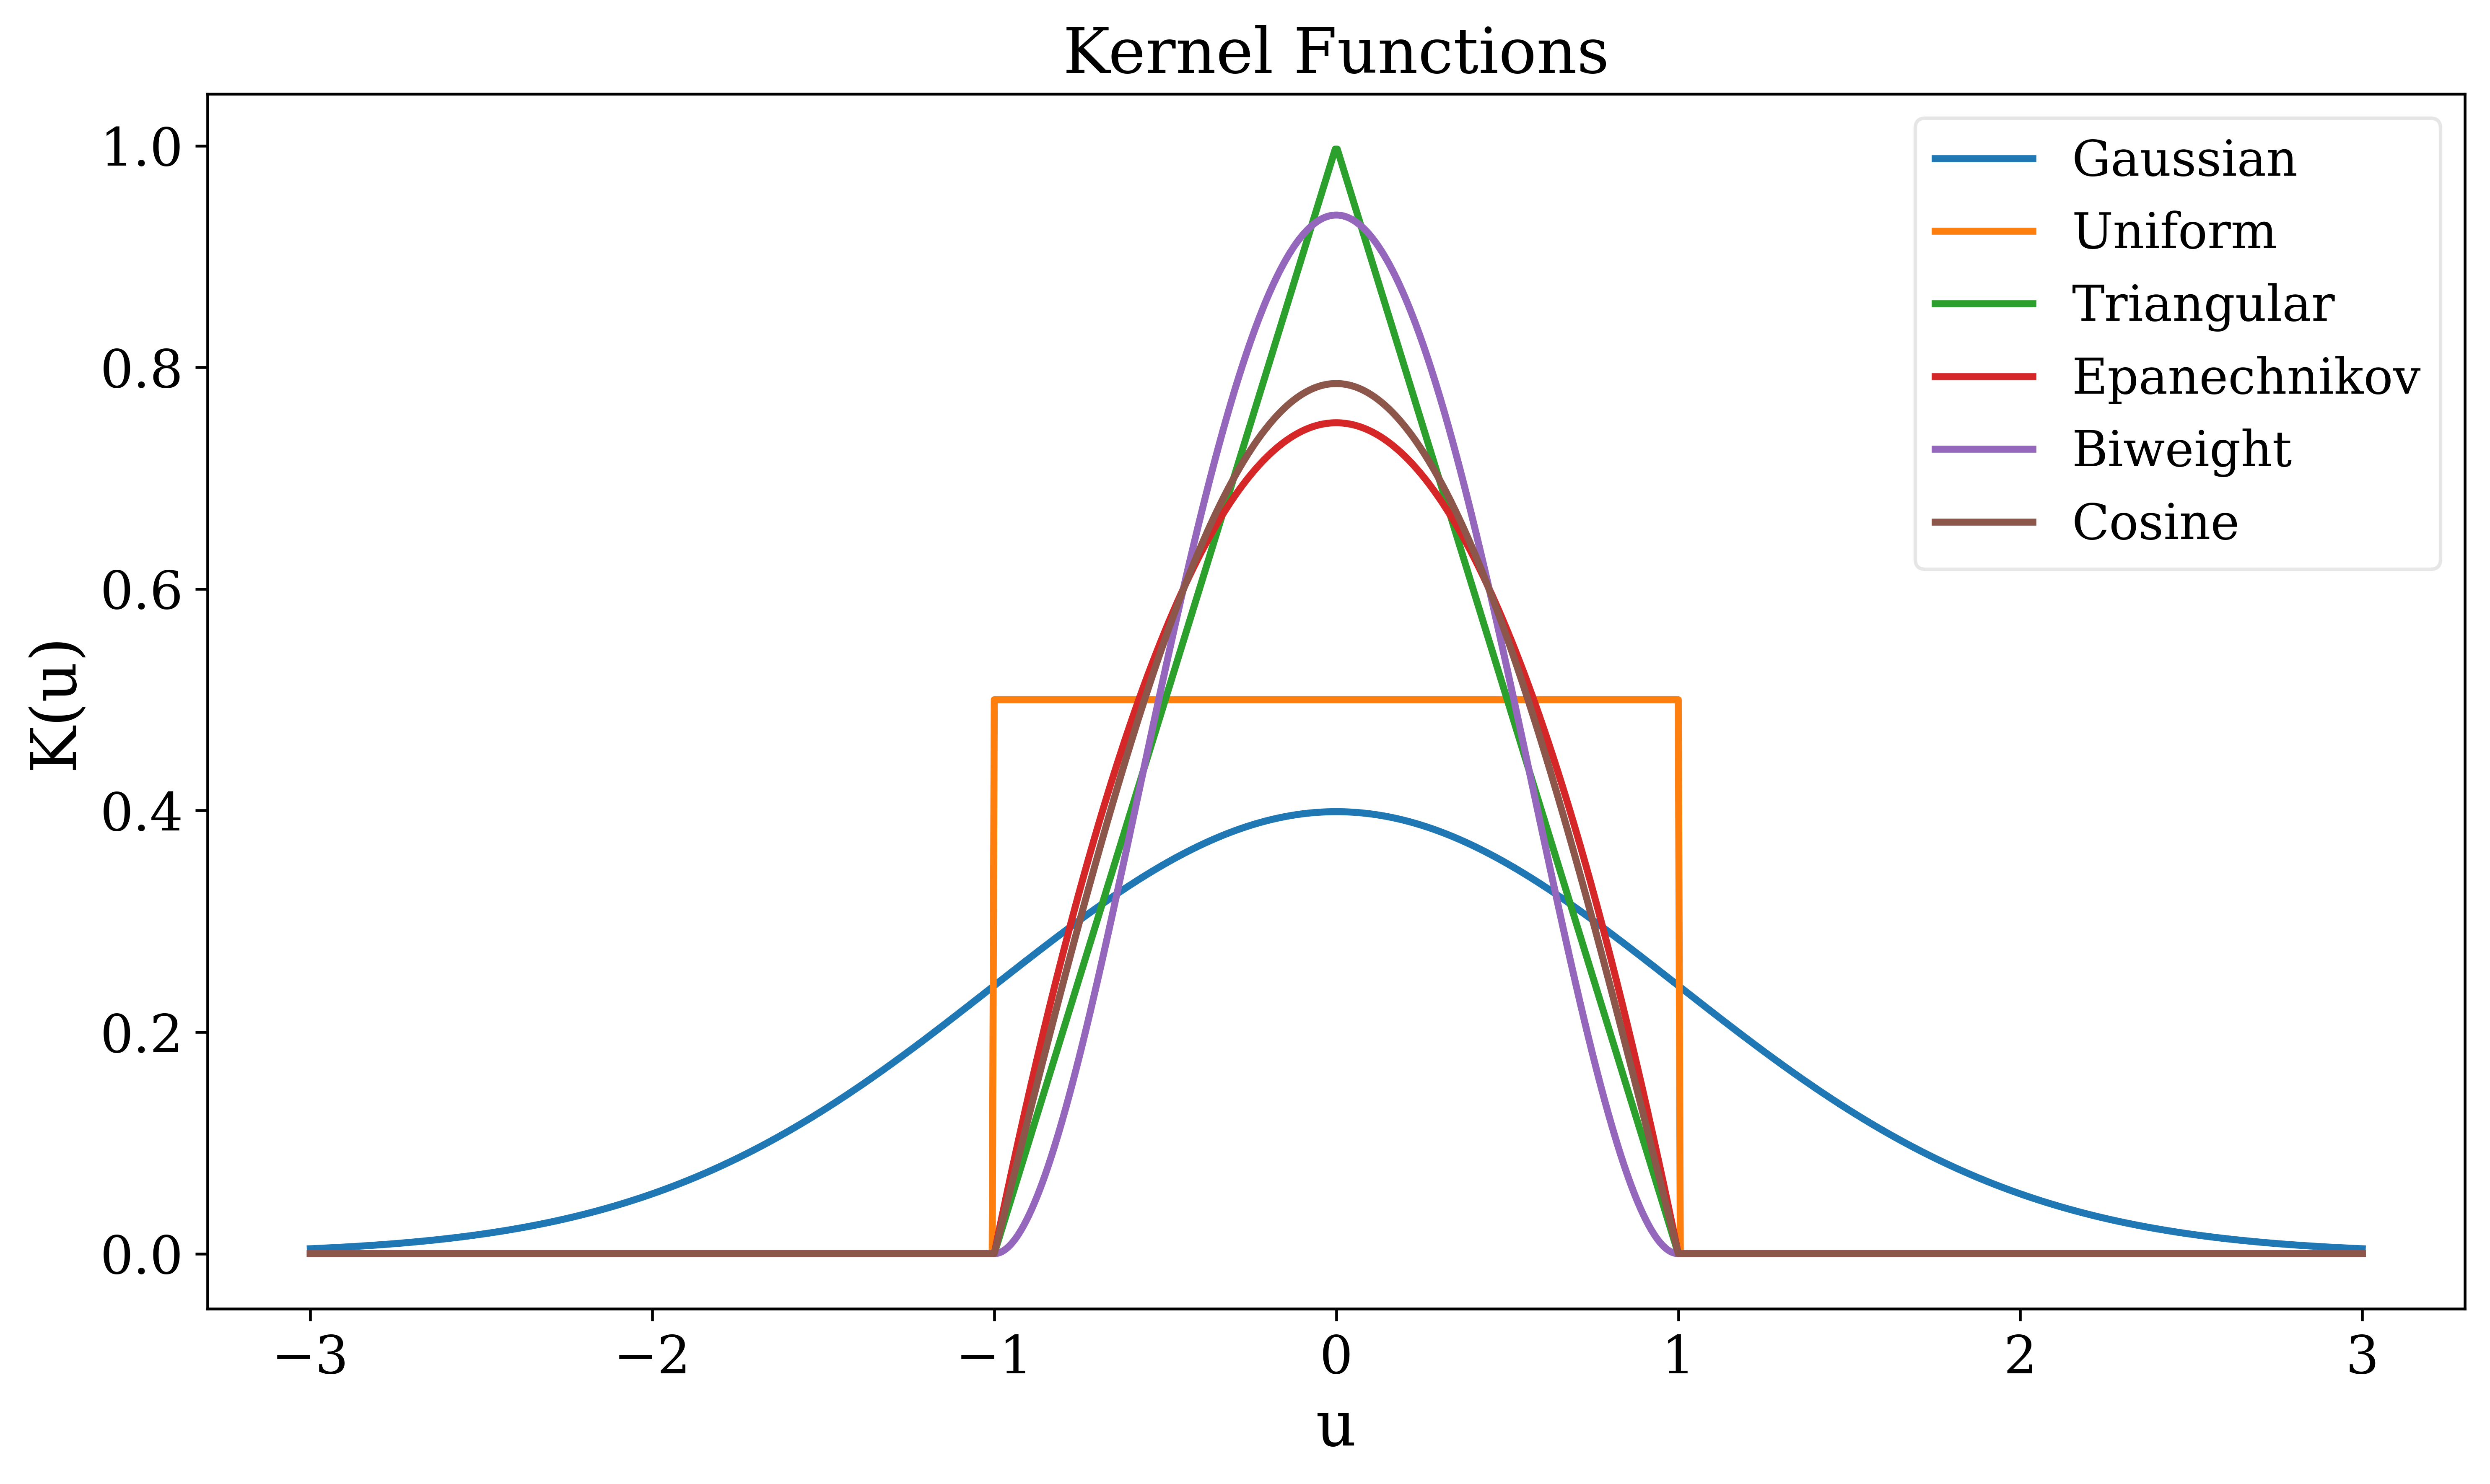

In [15]:
u_grid = np.linspace(-3.0, 3.0, 1000)

plt.figure(figsize=(10, 6))
for kernel_name, kernel_function in kernel_functions.items():
    plt.plot(u_grid, kernel_function(u_grid), linewidth=2, label=kernel_name)

plt.xlabel("u")
plt.ylabel("K(u)")
plt.title("Kernel Functions")
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()

## 6. KDE from the same data using different kernels

We now fix the data and the bandwidth \(h\), and only change the kernel function.

This lets us see how the kernel shape affects the final KDE.

In [16]:
def kde_estimate(
    x_grid: np.ndarray,
    observations: np.ndarray,
    bandwidth: float,
    kernel_function: Callable[[np.ndarray], np.ndarray],
) -> np.ndarray:
    density = np.zeros_like(x_grid, dtype=float)

    for observation in observations:
        u = (x_grid - observation) / bandwidth
        density += kernel_function(u)

    return density / (observations.size * bandwidth)

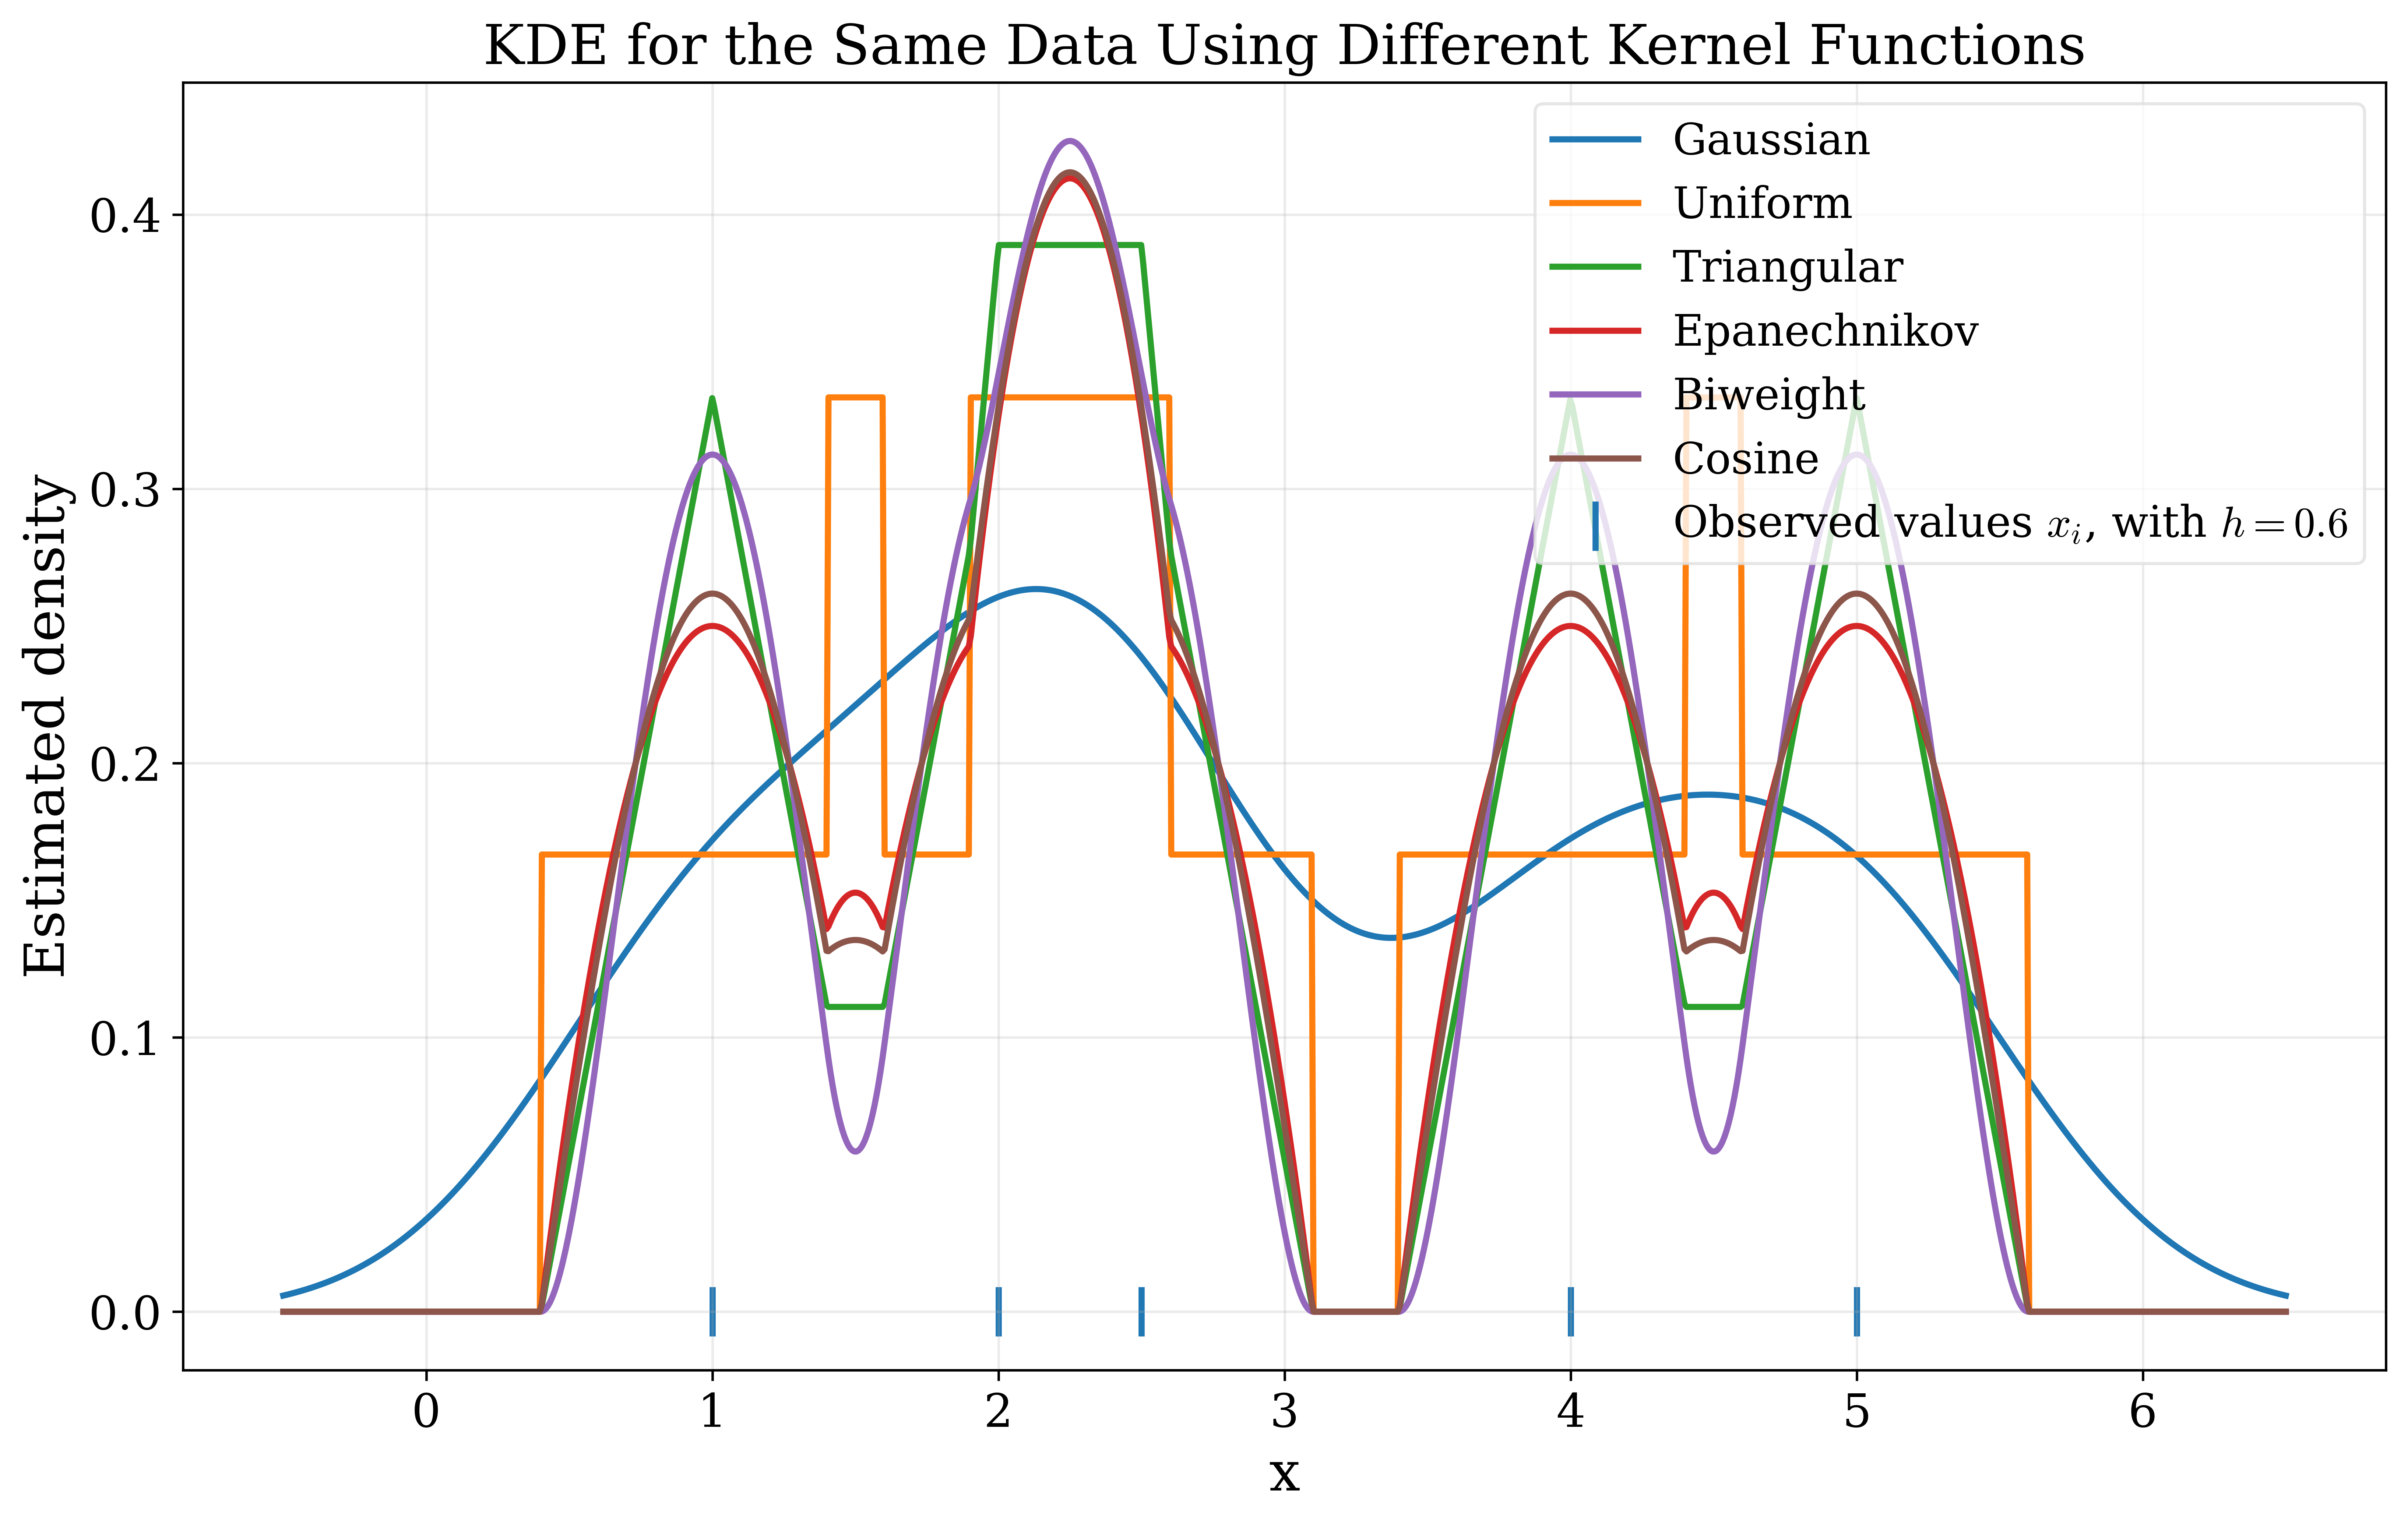

In [17]:
plt.figure(figsize=(11, 7))
for kernel_name, kernel_function in kernel_functions.items():
    density = kde_estimate(
        x_grid=x_grid,
        observations=observations,
        bandwidth=bandwidth,
        kernel_function=kernel_function,
    )
    plt.plot(x_grid, density, linewidth=2, label=kernel_name)

plt.scatter(
    observations,
    np.zeros_like(observations),
    marker="|",
    s=260,
    linewidths=2,
    label=rf"Observed values $x_i$, with $h={bandwidth}$",
)

plt.xlabel("x")
plt.ylabel("Estimated density")
plt.title("KDE for the Same Data Using Different Kernel Functions")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

Main takeaway:

- the **overall pattern** remains similar,
- the **exact shape** changes slightly with the kernel,
- in practice, **bandwidth matters more than kernel choice**.

## 7. Effect of bandwidth \(h\) with fixed data

We keep the same observations and compare different values of \(h\).

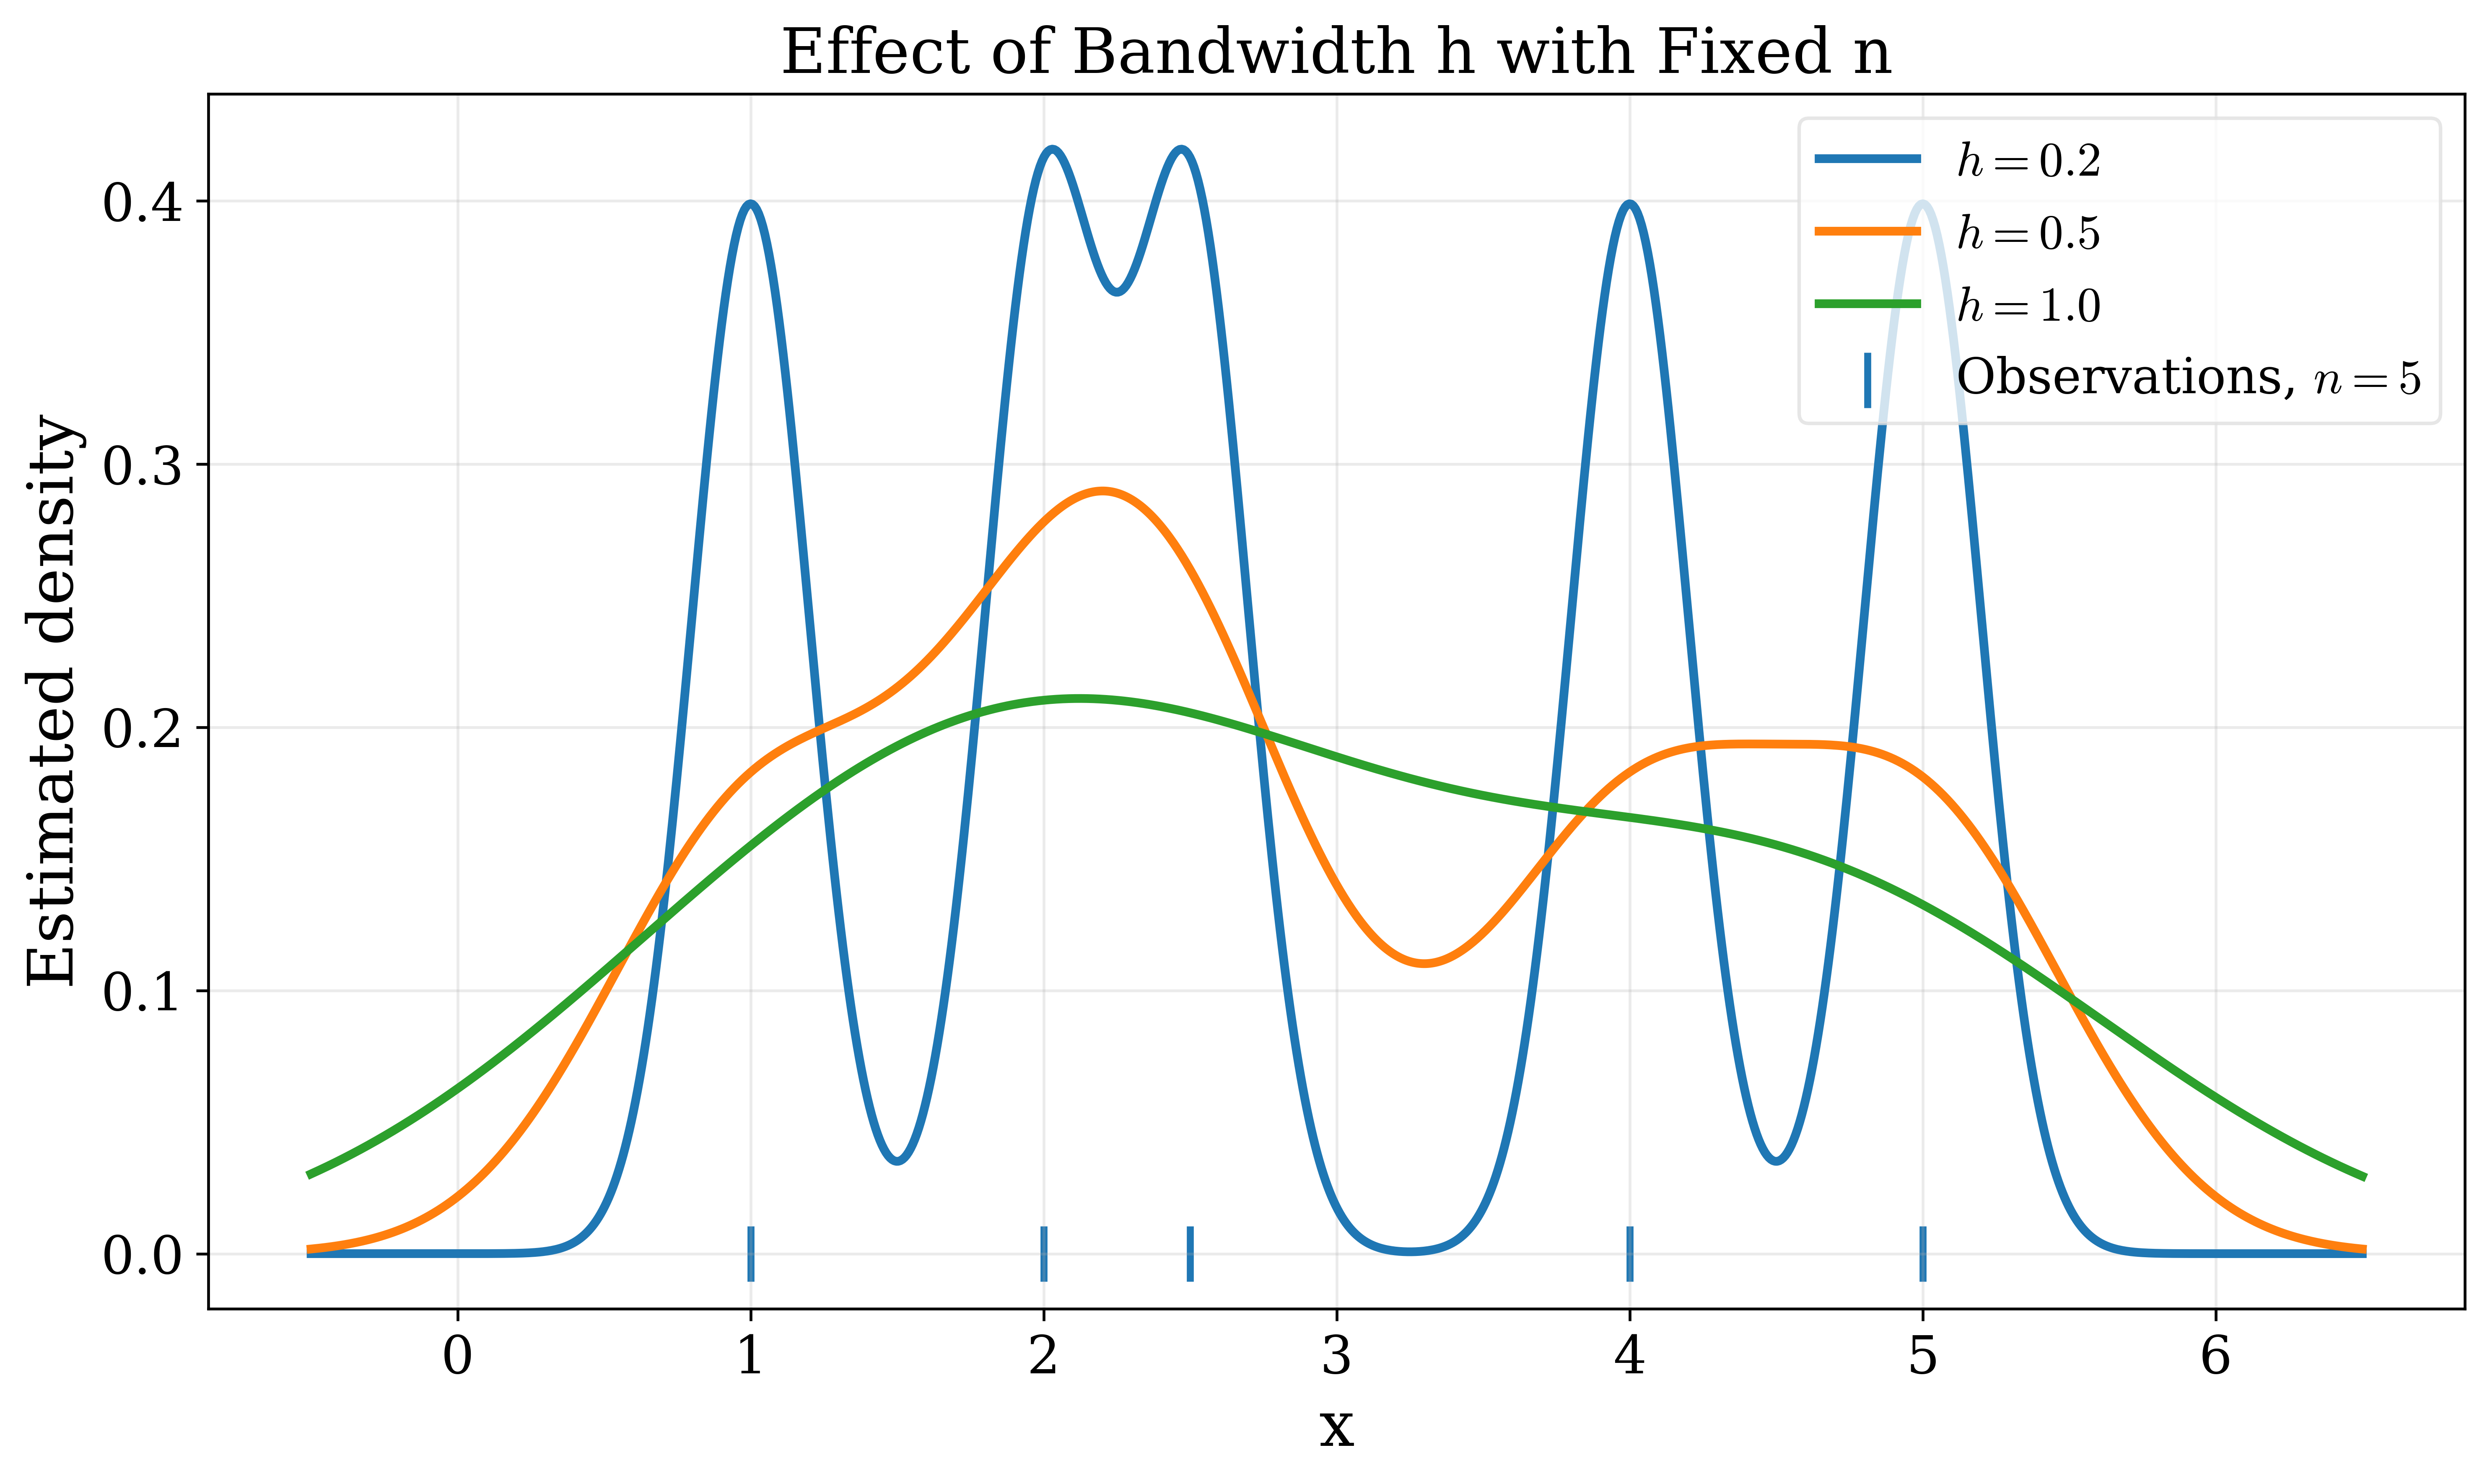

In [18]:
bandwidth_values = [0.2, 0.5, 1.0]

plt.figure(figsize=(10, 6))
for h_value in bandwidth_values:
    density = kde_estimate(
        x_grid=x_grid,
        observations=observations,
        bandwidth=h_value,
        kernel_function=gaussian_kernel,
    )
    plt.plot(x_grid, density, linewidth=2.5, label=rf"$h={h_value}$")

plt.scatter(
    observations,
    np.zeros_like(observations),
    marker="|",
    s=250,
    linewidths=2,
    label=rf"Observations, $n={observations.size}$",
)

plt.xlabel("x")
plt.ylabel("Estimated density")
plt.title("Effect of Bandwidth h with Fixed n")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

- Small \(h\): narrow kernels, many local peaks, more sensitivity to noise.
- Medium \(h\): more balanced smoothing.
- Large \(h\): wide kernels, smoother curve, possible loss of detail.

So:

\[
oxed{h 	ext{ controls smoothness}}
\]

## 8. Effect of sample size \(n\) with fixed bandwidth

Now we keep the bandwidth fixed and use progressively more observations.

Important idea:

\[
n = 	ext{number of observations}
\]

Unlike \(h\), it is not a tuning parameter in the same sense.

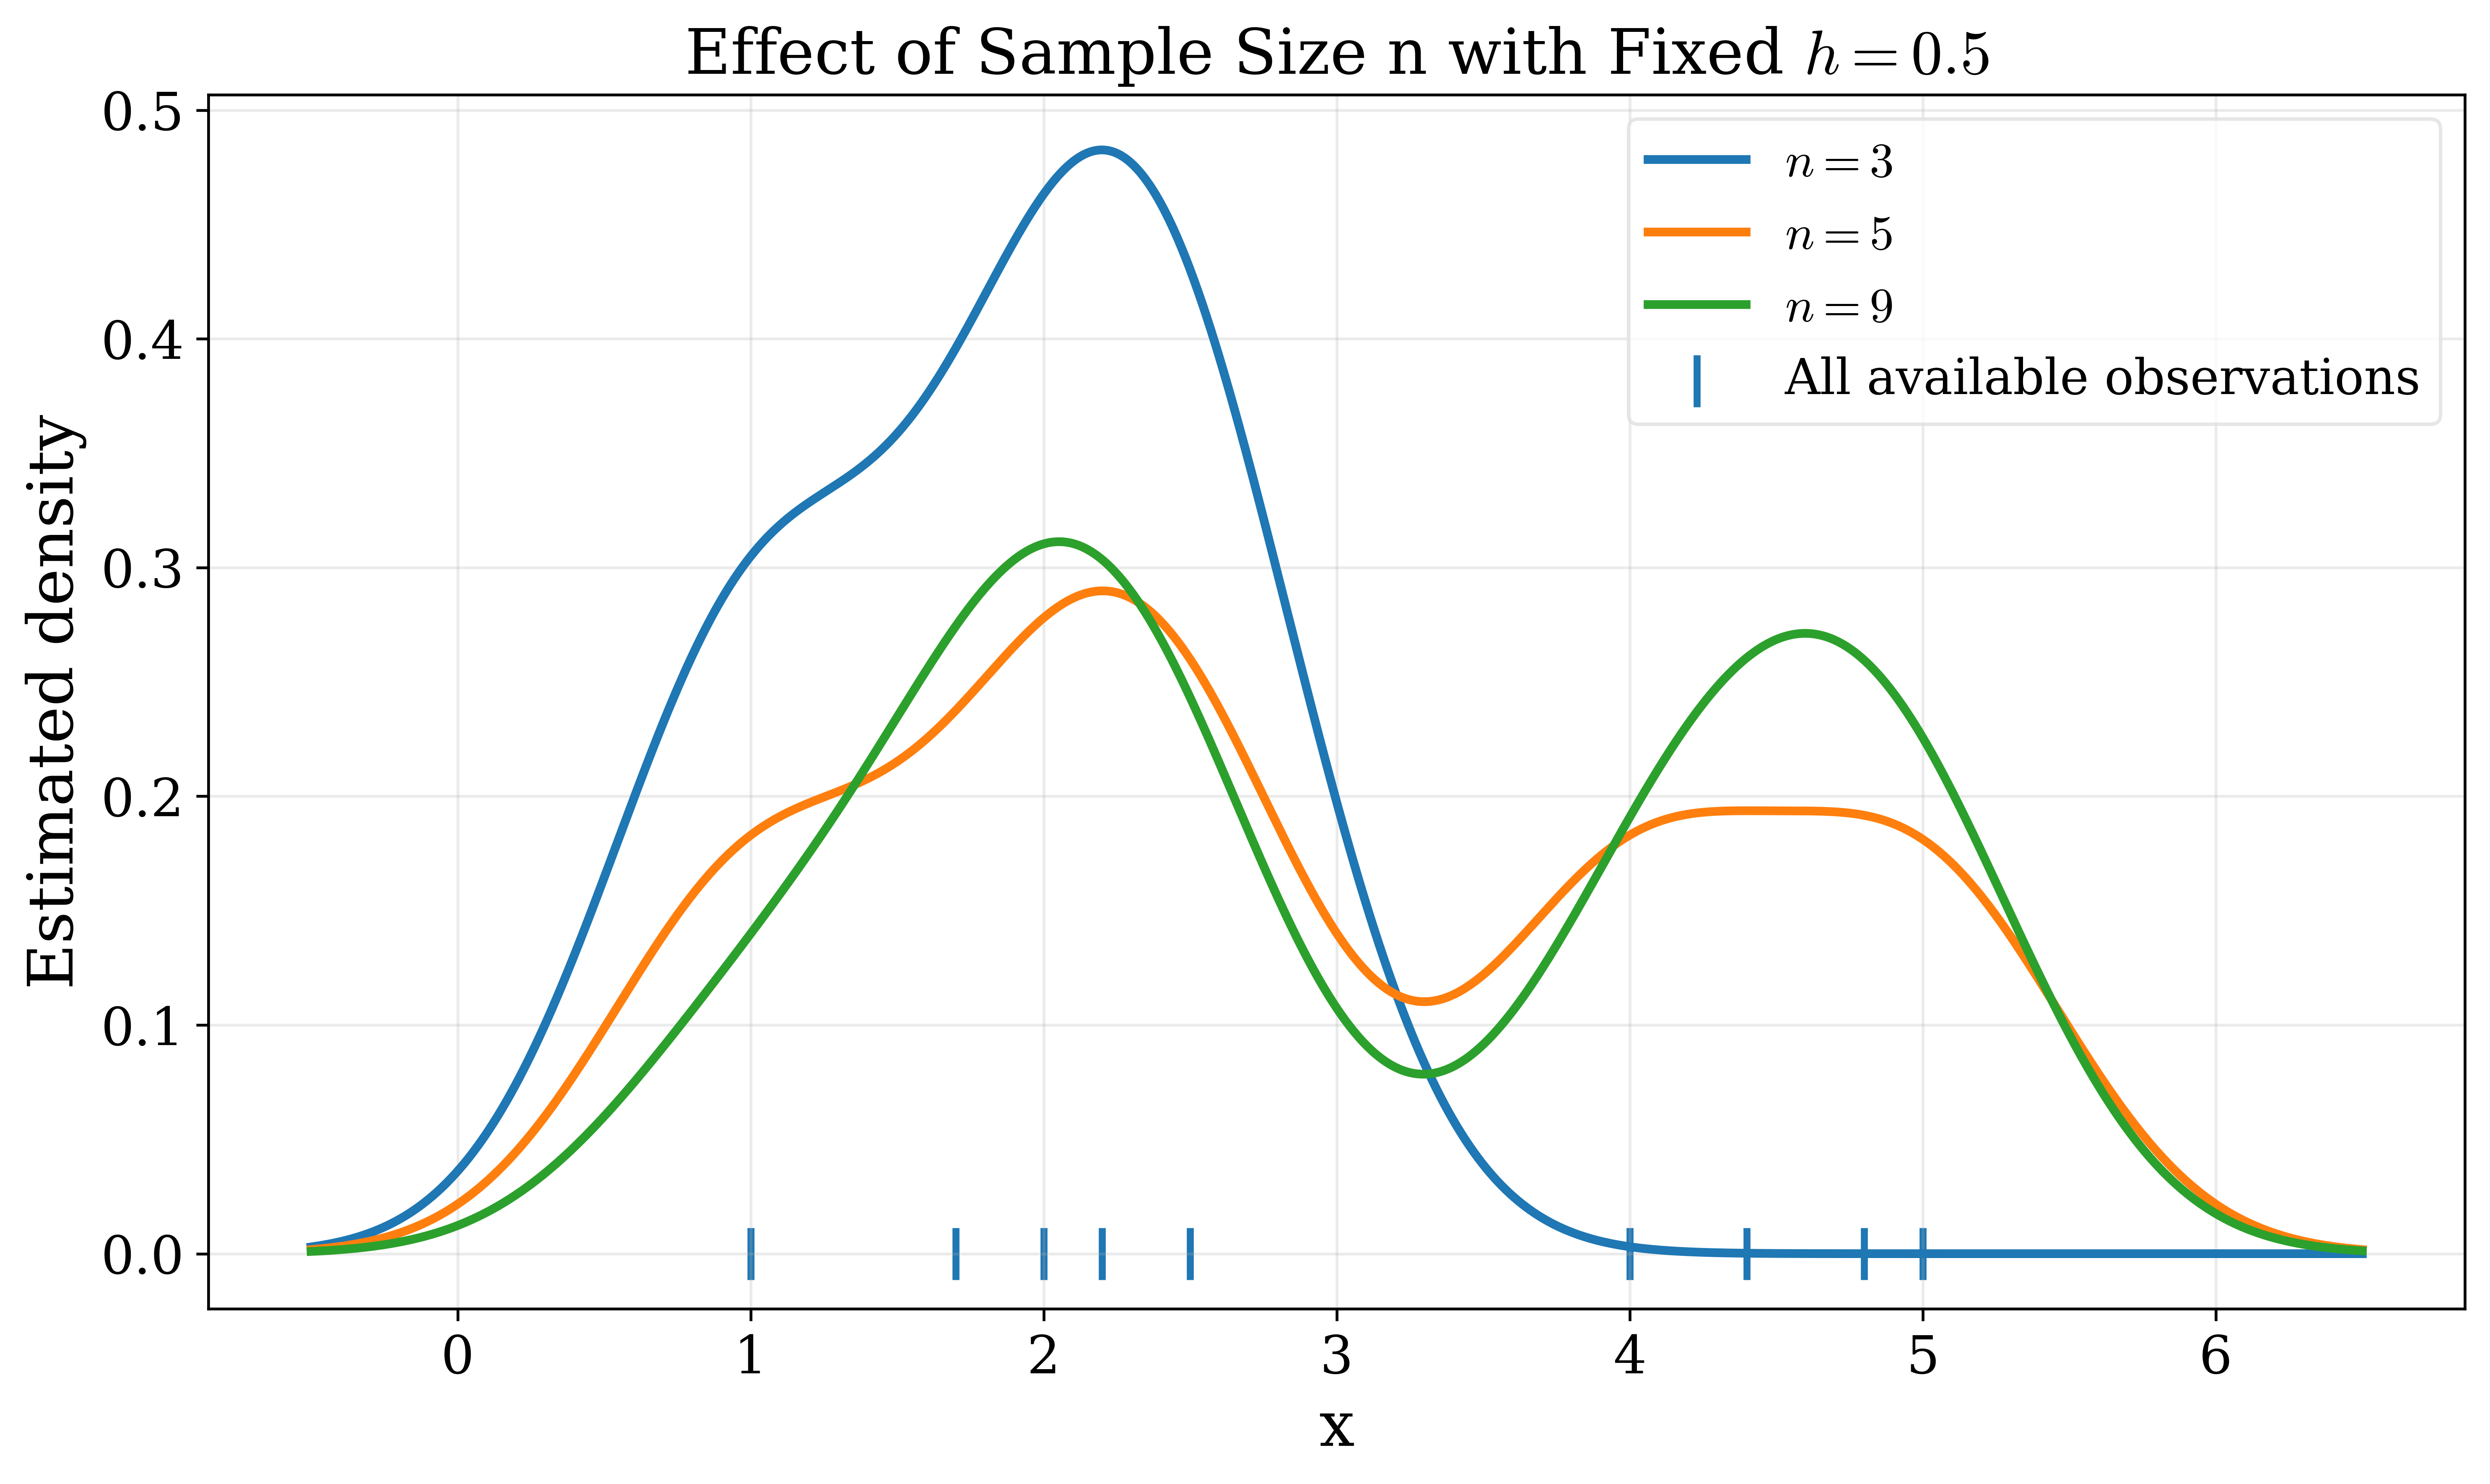

In [19]:
all_observations = np.array([1.0, 2.0, 2.5, 4.0, 5.0, 1.7, 2.2, 4.4, 4.8])
sample_sizes = [3, 5, 9]
fixed_h = 0.5

plt.figure(figsize=(10, 6))
for sample_size in sample_sizes:
    current_observations = all_observations[:sample_size]
    density = kde_estimate(
        x_grid=x_grid,
        observations=current_observations,
        bandwidth=fixed_h,
        kernel_function=gaussian_kernel,
    )
    plt.plot(x_grid, density, linewidth=2.5, label=rf"$n={sample_size}$")

plt.scatter(
    all_observations,
    np.zeros_like(all_observations),
    marker="|",
    s=220,
    linewidths=2,
    label="All available observations",
)

plt.xlabel("x")
plt.ylabel("Estimated density")
plt.title(r"Effect of Sample Size n with Fixed $h=0.5$")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

- smaller \(n\): less stable estimate,
- larger \(n\): more reliable estimate of the density.

So:

\[
oxed{n 	ext{ controls how much data contributes}}
\]

while

\[
oxed{h 	ext{ controls how much each observation spreads}}
\]

## 9. One-observation view: what a kernel does

For a single observation \(x_i\), the kernel says:

- points near \(x_i\) get high weight,
- points far from \(x_i\) get low weight.

So the main idea of a kernel is:

\[
oxed{	ext{spread each observed point over a nearby region}}
\]

This is why KDE can turn discrete observations into a smooth density estimate.